In [1]:
#导入需要的库和加载数据集
#看一下数据集各字段的含义以及数据类型
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
plt.rcParams['font.sans-serif']='SimHei'
df=pd.read_csv("D:\\银行客户认购预测数据集\\bank_data.csv",encoding='utf-8')
df.info()
df.head()

D:\Anaconda\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22500 entries, 0 to 22499
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                22500 non-null  int64  
 1   age               22500 non-null  int64  
 2   job               22499 non-null  object 
 3   marital           22498 non-null  object 
 4   education         22500 non-null  object 
 5   default           22498 non-null  object 
 6   housing           22497 non-null  object 
 7   loan              22497 non-null  object 
 8   contact           22498 non-null  object 
 9   month             22496 non-null  object 
 10  day_of_week       22497 non-null  object 
 11  duration          22500 non-null  int64  
 12  campaign          22499 non-null  float64
 13  pdays             22498 non-null  float64
 14  previous          22498 non-null  float64
 15  poutcome          22499 non-null  object 
 16  emp_var_rate      22499 non-null  float6

,id,age,job,marital,education,default,housing,loan,contact,month,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_index,cons_conf_index,lending_rate3m,nr_employed,subscribe
0,1,51,admin.,divorced,professional.course,no,yes,yes,cellular,aug,...,1.0,112.0,2.0,failure,1.4,90.81,-35.53,0.69,5219.74,no
1,2,50,services,married,high.school,unknown,yes,no,cellular,may,...,1.0,412.0,2.0,nonexistent,-1.8,96.33,-40.58,4.05,4974.79,yes
2,3,48,blue-collar,divorced,basic.9y,no,no,no,cellular,apr,...,0.0,1027.0,1.0,failure,-1.8,96.33,-44.74,1.50,5022.61,no
3,4,26,entrepreneur,single,high.school,yes,yes,yes,cellular,aug,...,26.0,998.0,0.0,nonexistent,1.4,97.08,-35.55,5.11,5222.87,yes
4,5,45,admin.,single,university.degree,no,no,no,cellular,nov,...,1.0,240.0,4.0,success,-3.4,89.82,-33.83,1.17,4884.70,no


In [3]:
#进行数据预处理
df = df.drop_duplicates(keep='first')
df = df.dropna()
df = df.reset_index(drop=True)
df['education']=df['education'].replace(['basic.4y','basic.6y','basic.9y'],'basic')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22473 entries, 0 to 22472
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                22473 non-null  int64  
 1   age               22473 non-null  int64  
 2   job               22473 non-null  object 
 3   marital           22473 non-null  object 
 4   education         22473 non-null  object 
 5   default           22473 non-null  object 
 6   housing           22473 non-null  object 
 7   loan              22473 non-null  object 
 8   contact           22473 non-null  object 
 9   month             22473 non-null  object 
 10  day_of_week       22473 non-null  object 
 11  duration          22473 non-null  int64  
 12  campaign          22473 non-null  float64
 13  pdays             22473 non-null  float64
 14  previous          22473 non-null  float64
 15  poutcome          22473 non-null  object 
 16  emp_var_rate      22473 non-null  float6

,id,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_index,cons_conf_index,lending_rate3m,nr_employed
count,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000,22473.000000
mean,11263.831487,40.403684,1146.474036,3.364348,773.927157,1.316469,0.078445,93.548156,-39.877869,3.302359,5137.233821
std,6487.830546,12.082611,1432.563847,7.226504,326.978215,1.918800,1.573758,2.806269,5.804237,1.611746,170.622744
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,-3.400000,87.640000,-53.280000,0.600000,4715.420000
25%,5646.000000,32.000000,143.000000,1.000000,557.000000,0.000000,-1.800000,91.190000,-44.160000,1.430000,5008.510000
50%,11264.000000,38.000000,354.000000,1.000000,964.000000,0.000000,1.100000,93.540000,-40.600000,3.910000,5133.910000
75%,16882.000000,47.000000,1873.000000,3.000000,1005.000000,2.000000,1.400000,95.920000,-35.810000,4.830000,5267.440000
max,22500.000000,101.000000,5149.000000,57.000000,1048.000000,6.000000,1.400000,99.460000,-25.550000,5.270000,5489.500000


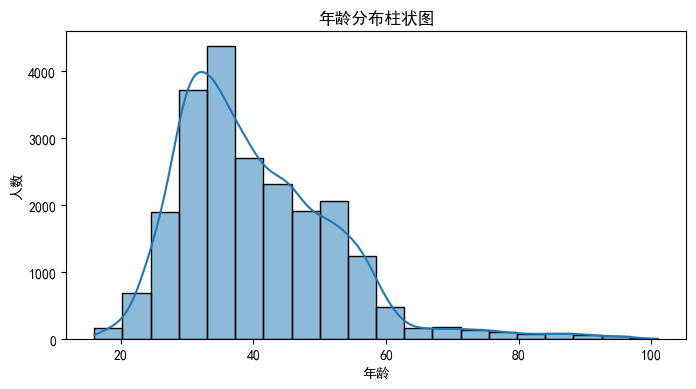

In [4]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('年龄分布柱状图')
plt.xlabel('年龄')
plt.ylabel('人数')
plt.show()

In [5]:
#从年龄分布柱状图可以看出：年龄在60岁以上的人数较少，且可能对实验结果造成不利影响，需要删除
#删除之后对年龄进行分组：30岁及以下，31-40岁，41-50岁，51-60岁
df=df[df['age']<=60].copy()
df['age_group']=pd.cut(df['age'],bins=[10,30,40,50,60],labels=['30岁及以下','31-40岁','41-50岁','51-60岁'])
df.head(30)

,id,age,job,marital,education,default,housing,loan,contact,month,...,pdays,previous,poutcome,emp_var_rate,cons_price_index,cons_conf_index,lending_rate3m,nr_employed,subscribe,age_group
0,1,51,admin.,divorced,professional.course,no,yes,yes,cellular,aug,...,112.0,2.0,failure,1.4,90.81,-35.53,0.69,5219.74,no,51-60岁
1,2,50,services,married,high.school,unknown,yes,no,cellular,may,...,412.0,2.0,nonexistent,-1.8,96.33,-40.58,4.05,4974.79,yes,41-50岁
2,3,48,blue-collar,divorced,basic,no,no,no,cellular,apr,...,1027.0,1.0,failure,-1.8,96.33,-44.74,1.50,5022.61,no,41-50岁
3,4,26,entrepreneur,single,high.school,yes,yes,yes,cellular,aug,...,998.0,0.0,nonexistent,1.4,97.08,-35.55,5.11,5222.87,yes,30岁及以下
4,5,45,admin.,single,university.degree,no,no,no,cellular,nov,...,240.0,4.0,success,-3.4,89.82,-33.83,1.17,4884.70,no,41-50岁
5,6,47,management,married,unknown,no,no,no,cellular,jul,...,10.0,3.0,nonexistent,1.4,94.58,-30.37,3.55,5257.02,no,41-50岁
6,7,33,technician,married,high.school,no,yes,no,cellular,aug,...,1009.0,0.0,nonexistent,1.4,94.93,-35.12,4.74,5018.97,no,31-40岁
7,8,40,technician,married,basic,yes,no,unknown,cellular,apr,...,934.0,4.0,success,1.4,94.44,-33.52,4.61,5452.31,no,31-40岁
8,9,47,services,married,high.school,no,no,no,cellular,aug,...,959.0,0.0,nonexistent,1.4,95.40,-37.65,5.09,5358.80,no,41-50岁
9,10,53,housemaid,married,unknown,no,no,no,cellular,aug,...,594.0,6.0,success,-2.9,93.17,-28.27,2.30,4988.07,yes,51-60岁


In [6]:
#通过可视化工具，分析一下年龄对最终的购买结果是否有影响
df1=df.groupby(['age_group','subscribe']).size().unstack()
df1['购买比例']=df1['yes']/(df1['yes']+df1['no'])
df1
#通过结果可以看出，30岁及以下最终购买的比例远远高于其他年龄段
#在后续的推销过程中，我们可以把更多的精力放在30岁及以下的人群

subscribe,no,yes,购买比例
age_group,,,
30岁及以下,3826,757,0.165176
31-40岁,7513,881,0.104956
41-50岁,4843,442,0.083633
51-60岁,2759,388,0.123292


In [7]:
#再看下其他因素是否会对最终购买结果产生影响
df2=df.groupby(['housing','subscribe']).size().unstack()
df2['购买比例']=df2['yes']/(df2['yes']+df2['no'])
df2
#有房贷和无房贷中最够购买的比例几乎一样，说明是否有房贷这个因素对结果基本没影响

subscribe,no,yes,购买比例
housing,,,
no,8555,1067,0.110892
unknown,553,126,0.185567
yes,9833,1275,0.114782


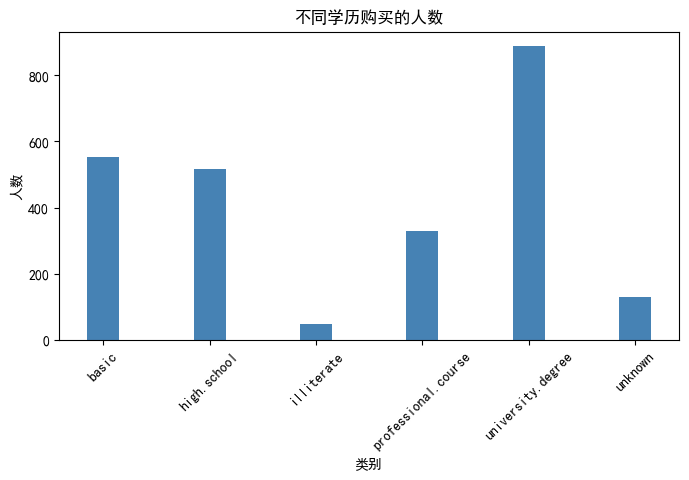

In [8]:
data=df[df['subscribe']=='yes']
count=data['education'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(count.index,count.values,width=0.3,color='steelblue')
plt.title('不同学历购买的人数')
plt.xlabel('类别')
plt.ylabel('人数')
plt.xticks(rotation=45)
plt.show()
#从结果可以看出，学历为university。degree最终购买的人数最多。

In [9]:
#在我们的认知里，之前有过购买记录的人再次购买的概率往往更高
#是不是真的这样？
df3=df.groupby(['poutcome','subscribe']).size().unstack()
df3['购买比例']=df3['yes']/(df3['yes']+df3['no'])
df3
#结果证明：确实是这样。
#在今后的推销过程中，我们可以优先关注那些有过购买记录的人。

subscribe,no,yes,购买比例
poutcome,,,
failure,3627,550,0.131673
nonexistent,12648,1348,0.096313
success,2666,570,0.176143


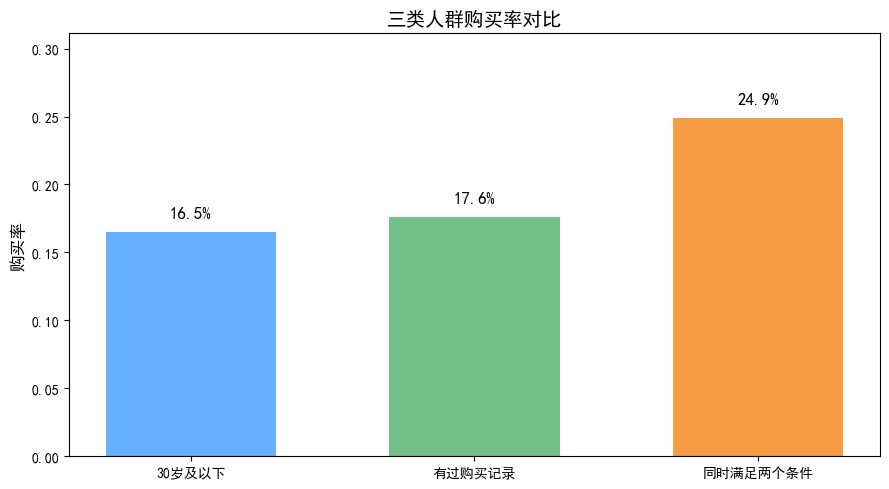

subscribe,no,yes
young_and_purchased,,
0,18371,2279
1,570,189


In [17]:
#既然年龄和之前是否有过购买记录都会对结果造成影响
#我们是不是可以尝试：将两者结合起来，看能不能得到更高的购买率
df['is_subscribe'] = df['subscribe'].map({'yes':1, 'no':0}).fillna(0)
df['is_young'] = (df['age_group'] == '30岁及以下').astype(int)
df['had_previous_purchase'] = (df['poutcome'] == 'success').astype(int)
rate1 = df[df["is_young"] == 1]["is_subscribe"].mean()
rate2 = df[df["poutcome"] == "success"]["is_subscribe"].mean()
rate3 = df[(df["is_young"] == 1) & (df["poutcome"] == "success")]["is_subscribe"].mean()
y = [rate1, rate2, rate3]
y = [0 if np.isnan(val) else val for val in y]
x_labels = ["30岁及以下", "有过购买记录", "同时满足两个条件"]
plt.figure(figsize=(9,5))
plt.bar(x_labels, y, color=["#66b1ff", "#73c088", "#f59b42"], width=0.6)
plt.ylabel("购买率", fontsize=12)
plt.title("三类人群购买率对比", fontsize=14)
for idx, val in enumerate(y):
    plt.text(idx, val + 0.01, f"{val:.1%}", ha="center", fontsize=12)
max_y = max(y) if max(y) > 0 else 0.1
plt.ylim(0, max_y * 1.25)
plt.tight_layout()
plt.show()
df['young_and_purchased']=df['is_young']*df['had_previous_purchase']
df5=df.groupby(['young_and_purchased','subscribe']).size().unstack()
df5
#结果显示：结合之后，购买率果然有所上升，30岁及以下的购买率为16.5%，有过购买记录的购买率为17.6%，而两者都满足的购买率却达到24.9%
#但也存在一定的问题：同时满足两个条件的人数占总人数的比例太小了，仅占3%
#在现实生活中，想要找到满足两个条件的人的概率太低了
#能不能找到一个方法：既能保证购买率，还能保证这样的人数不会太低

In [23]:
#基于用户是否购买构建二分类逻辑回归模型，计算出30岁及以下和有过购买记录这两个特征的权重系数，模型截距
X=df[['is_young','had_previous_purchase']]
y=df['is_subscribe']
model=LogisticRegression(penalty='l2',C=1e10,random_state=42)
model.fit(X,y)
w1=model.coef_[0][0]
w2=model.coef_[0][1]
b=model.intercept_[0]
print(f"w1 (is_young)={w1:.4f}")
print(f"w2 (had_previous_purchase)={w2:.4f}")
print(f"截距 b={b:.4f}")
df['weighted_score']=b+w1*df['is_young']+w2*df['had_previous_purchase']

w1 (is_young)=0.5497
w2 (had_previous_purchase)=0.5960
截距 b=-2.2854


D:\Anaconda\lib\site-packages\seaborn\utils.py:95: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()
C:\Users\14686\AppData\Local\Temp\ipykernel_17884\1229609680.py:16: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\14686\AppData\Local\Temp\ipykernel_17884\1229609680.py:17: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
D:\Anaconda\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


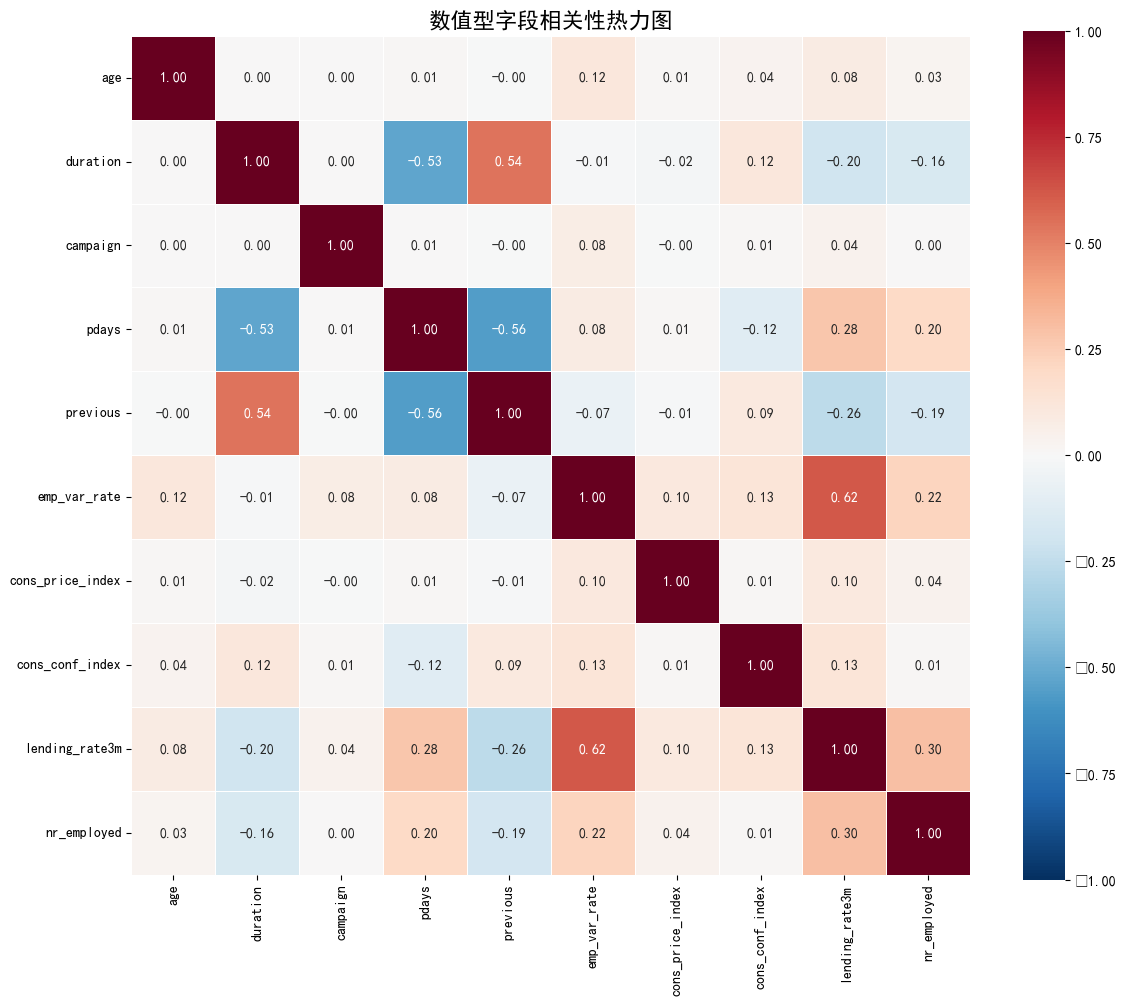

In [19]:
#画一张数值型字段的相关性热力图，分析一下各字段的相关性
numeric_cols = ['age', 'duration','campaign','pdays','previous','emp_var_rate','cons_price_index','cons_conf_index','lending_rate3m','nr_employed']
df_num = df[numeric_cols]
corr_matrix = df_num.corr()
plt.figure(figsize=(12, 10))  
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",         
    cmap="RdBu_r",     
    vmin=-1, vmax=1,   
    linewidths=0.5,    
    square=True        
)
plt.title("数值型字段相关性热力图", fontsize=16)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
#从热力图可以看出：上一次与客户联系的时长(campaign)和上一次与客户联系后的间隔天数(pdays)呈现比较强的负相关，上一次与客户联系后的间隔天数(pdays)和在本次营销活动前，与客户联系的次数(previous)也呈现较强的负相关，银行利率(lending_rate3m)和就业变动率(emp_var_rate)呈现较强的正相关
#以上结论都是比较符合常识的

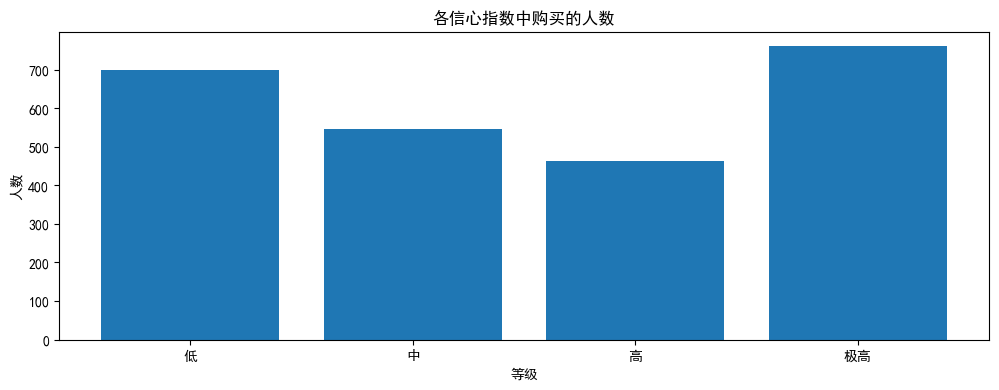

In [20]:
#但我关注到另一个字段：消费者信心指数(cons_conf_index)
#通常情况下，消费者信心指数越高，最终的购买率也会更高
data3=df.copy()
data3['消费者信心指数']=pd.cut(data3['cons_conf_index'],bins=[-54,-44,-40,-36,-25],labels=['低','中','高','极高'],right=False)
data4=data3[data3['subscribe']=='yes']
count1=data4['消费者信心指数'].value_counts().sort_index()
plt.figure(figsize=(12,4))
plt.bar(count1.index,count1.values,width=0.8)
plt.title('各信心指数中购买的人数')
plt.xlabel('等级')
plt.ylabel('人数')
plt.show()
#通过柱状图可以看出，结果似乎与我们预想的不一样
#在各组人数相同的情况下，虽然信心指数极高的人群，购买的人数是最多的，但信心指数为中和高的人群的购买人数却呈现递减趋势，且低于信心指数为低的人群

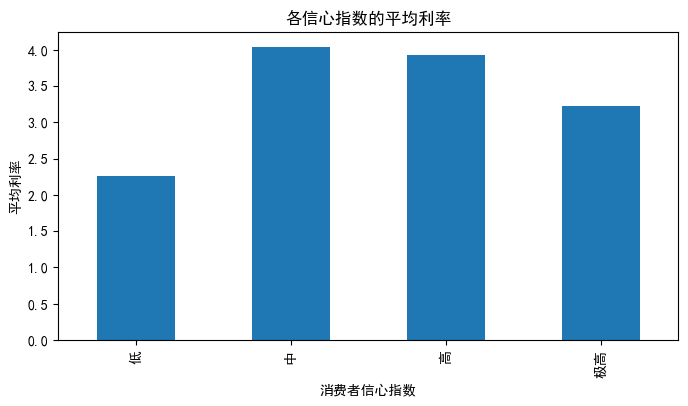

In [21]:
#我的初步猜想是：是不是利率的原因？
#于是我又做了一个实验：比较一下各组信心指数的平均利率
mean_rates=data3.groupby('消费者信心指数',observed=False)['lending_rate3m'].mean()
mean_rates.plot(kind='bar',figsize=(8,4),title='各信心指数的平均利率')
plt.ylabel('平均利率')

plt.show()
#在信心指数为中和高的人群中，利率远远高于信心指数为低和极高的人群
#有理由怀疑，就是利率导致了该反常现象的出现

In [22]:
#通过逻辑回归模型，计算出利率这个特征的回归系数
#对利率这个因素特征进行等频分组：低利率、中利率、高利率，并计算出不同利率组的最终购买概率
data3['conf_level']=data3['消费者信心指数'].map({'低':0,'中':1,'高':2,'极高':3})
X=data3[['lending_rate3m','conf_level']]
y=(data3['subscribe']=='yes').astype(int)
model=LogisticRegression()
model.fit(X,y)
print('利率系数:',model.coef_[0][0])
data3['rate_level']=pd.qcut(data3['lending_rate3m'],q=3,labels=['低利率','中利率','高利率'])
data3['is_subscribe']=(data3['subscribe']=='yes').astype(int)
print(data3.groupby('rate_level')['is_subscribe'].mean())

利率系数: -0.35423127581899144
rate_level
低利率    0.183776
中利率    0.099258
高利率    0.061847
Name: is_subscribe, dtype: float64


In [24]:
#在前面，我们已经计算出了每个用户的加权分，这里再细化，计算出不同利率组的加权分均值、10%分位数、50%分位数、90%分位数
for level in ['低利率','中利率','高利率']:
    subset=data3[data3['rate_level']==level]
    print(f'\n==={level}组 ===')
    print("购买者加权分 均值：",subset[subset['is_subscribe']==1]['weighted_score'].mean())
    print("购买者加权分 10%分位数：",subset[subset['is_subscribe']==1]['weighted_score'].quantile(0.1))
    print("购买者加权分 50%分位数：",subset[subset['is_subscribe']==1]['weighted_score'].quantile(0.5))
    print("购买者加权分 90%分位数：",subset[subset['is_subscribe']==1]['weighted_score'].quantile(0.9))


===低利率组 ===
购买者加权分 均值： -1.9403733391938436
购买者加权分 10%分位数： -2.285416365160989
购买者加权分 50%分位数： -1.7357441871610018
购买者加权分 90%分位数： -1.6894245413678268

===中利率组 ===
购买者加权分 均值： -1.9733956843561091
购买者加权分 10%分位数： -2.285416365160989
购买者加权分 50%分位数： -2.285416365160989
购买者加权分 90%分位数： -1.6894245413678268

===高利率组 ===
购买者加权分 均值： -2.106824442368857
购买者加权分 10%分位数： -2.285416365160989
购买者加权分 50%分位数： -2.285416365160989
购买者加权分 90%分位数： -1.7357441871610018


In [27]:
#为每个用户生成一个订购概率（prob）
#设计对照实验：随机选取2000条数据，比较方法A（同时满足is_young=1和have_previous_purchase=1）和方法B（利率等级从低到高、同利率组内再按订阅概率从高到低的排序方法）
features = ['is_young', 'had_previous_purchase', 'lending_rate3m']  
X = data3[features]
y = data3['is_subscribe']
model = LogisticRegression(penalty='none', max_iter=1000, random_state=42)
model.fit(X, y)
data3['prob'] = model.predict_proba(X)[:, 1]  
print("系数:")
print(f"is_young: {model.coef_[0][0]:.4f}")
print(f"had_previous_purchase: {model.coef_[0][1]:.4f}")
print(f"lending_rate3m: {model.coef_[0][2]:.4f}")
print(f"截距: {model.intercept_[0]:.4f}")
data3['sort_key'] = data3['rate_level'].map({'低利率': 1, '中利率': 2, '高利率': 3})
candidates = data3.sort_values(['sort_key', 'prob'], ascending=[True, False])
sample = data3.sample(n=2000, random_state=20)
method_a = sample[(sample['is_young'] == 1) & (sample['had_previous_purchase'] == 1)]
n_a = len(method_a)
tp_a = method_a['is_subscribe'].sum()
method_b = sample.nlargest(n_a, 'prob') if n_a > 0 else sample.head(0)
tp_b = method_b['is_subscribe'].sum()
print("="*50)
print(f"随机抽样2000条数据")
print(f"方法A（原始规则）：选出 {n_a} 人，其中真实购买人数 = {tp_a}")
print(f"方法B（概率模型）：选出相同人数 ({n_a})，其中真实购买人数 = {tp_b}")
print(f"方法B 比 方法A 多找到真实购买者: {tp_b - tp_a} 人")
print(f"方法B 的提升比例: {(tp_b - tp_a)/tp_a*100:.1f}% ")

系数:
is_young: 0.4820
had_previous_purchase: 0.3764
lending_rate3m: -0.3182
截距: -1.2747
随机抽样2000条数据
方法A（原始规则）：选出 76 人，其中真实购买人数 = 22
方法B（概率模型）：选出相同人数 (76)，其中真实购买人数 = 32
方法B 比 方法A 多找到真实购买者: 10 人
方法B 的提升比例: 45.5% 


In [ ]:
#经过一系列操作，我们可以看到：方法B不仅提高了购买概率，同时还能保证满足条件的人数尽可能的多
#再以后的推销过程中，我们就可以采取这样的方法：先计算出客户的订购概率（prob），选择订购概率较高的人进行推销，尽可能降低我们的推销成本，并获得尽可能多的收益